# Сравнение моделей instance-сегментации на CarDD

Ноутбук сравнивает финальные модели **Mask R-CNN** и **Mask2Former** (чекпойнты — из W&B) на **одном и том же тестовом сплите** CarDD, по одному протоколу.

Ноутбук только **считает и показывает** метрики; интерпретация — отдельно.

**Содержание:**
1. Загрузка моделей из W&B
2. Параметры обучения: число параметров, эпохи, время обучения
3. COCO mAP (bbox + segm) + лепестковые диаграммы Precision (AP) и Recall (AR)
4. Относительное падение AP при ужесточении порога IoU
5. Время инференса
6. Классификация и подсчёт: число объектов по классам, confusion matrix
7. Дополнительно: AP по классам, «качество vs скорость», сводная таблица

**Условия честности:** один test-сплит, один порог score при сборе предсказаний, один COCO-evaluator, одно железо, замеры в одной сессии.

## 0. Установка и импорты

In [9]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.2 MB/s eta 0:00:00


In [10]:
import os
import json
import random
import time
import logging
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import torch
from PIL import Image
from ultralytics import YOLO

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.ops import box_convert

from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as mask_utils

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 2026
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CLASS_NAMES = ["dent", "scratch", "crack", "glass_shatter", "lamp_broken", "tire_flat"]
NUM_CLASSES = 6
IMG_SIZE = 512

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
device: cuda


In [2]:
LOG_DIR = Path("logs")
LOG_DIR.mkdir(exist_ok=True)
_log_file = LOG_DIR / f"models_сomparison{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

formatter = logging.Formatter("%(asctime)s %(levelname)s %(message)s")

log = logging.getLogger("models_сomparison")
log.setLevel(logging.INFO)
log.handlers.clear()

log.addHandler(logging.StreamHandler())
log.addHandler(logging.FileHandler(_log_file, encoding="utf-8"))

for h in log.handlers:
    h.setFormatter(formatter)

log.propagate = False
log.info(f"device: {device} | log: {_log_file}")

2026-06-16 00:34:45,519 INFO device: cuda | log: logs/mask2former_20260616_003445.log


### Данные (тестовый сплит CarDD)

In [4]:
# !gdown --fuzzy https://drive.google.com/file/d/1KSxPuDzh35MXCqoavWU742XLdQQVWQjd/view?usp=sharing -O /content/CarDD_COCO.zip
!unzip -q /content/CarDD_COCO.zip -d /content/

In [5]:
data_root = Path("/content/CarDD_COCO")
TEST_IMG_DIR = data_root / "test2017"
TEST_ANN = data_root / "annotations" / "instances_test2017.json"

coco_gt = COCO(str(TEST_ANN))
img_ids = sorted(coco_gt.imgs.keys())
log.info(f"test: {len(img_ids)} изображений, {len(coco_gt.anns)} объектов")

2026-06-16 00:36:45,334 INFO test: 374 изображений, 785 объектов


loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


## 1. Загрузка моделей из W&B

Берём **модели лучших запусков** (артефакты W&B).

In [6]:
import wandb
wandb.login()

ENTITY = "maty11-hse"
PROJECT_MASK_RCNN = "test_mask_r_cnn"
PROJECT_MASK2FORMER = "test_mask2former"
PROJECT_YOLO = "car_damage_yolov8"

MODELS = {
    "Mask R-CNN": {
        "proj_path": f"{ENTITY}/{PROJECT_MASK_RCNN}",
        "artifact": f"{ENTITY}/{PROJECT_MASK_RCNN}/maskrcnn_cardd_epoch5:v1",
        "ckpt_file": "maskrcnn_cardd_best.pt",
        "run_id": "4vv0m5js",
    },
    "Mask2Former": {
        "proj_path": f"{ENTITY}/{PROJECT_MASK2FORMER}",
        "artifact": f"{ENTITY}/{PROJECT_MASK2FORMER}/mask2former_cardd_epoch7:v0",
        "ckpt_file": "mask2former_cardd_best.pt",
        "run_id": "zu7nxuiv",
    },
    "YOLOv8": {
        "proj_path": f"{ENTITY}/{PROJECT_YOLO}",
        "artifact": f"{ENTITY}/{PROJECT_YOLO}/yolov8_results:v0",
        "ckpt_file": "weights/best.pt",
        "run_id": "trbcyiu6",
    },
}

api = wandb.Api()
for name, m in MODELS.items():
    art = api.artifact(m["artifact"])
    m["ckpt_path"] = os.path.join(art.download(), m["ckpt_file"])
    log.info(f"{name}: {m['ckpt_path']}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: maty11 (maty11-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Downloading large artifact 'maskrcnn_cardd_epoch5:v1', 175.51MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:09.0 (19.4MB/s)
2026-06-16 00:40:53,630 INFO Mask R-CNN: /content/artifacts/maskrcnn_cardd_epoch5:v1/maskrcnn_cardd_best.pt
wandb: Downloading large artifact 'mask2former_cardd_epoch7:v0', 181.07MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:12.0 (15.1MB/s)
2026-06-16 00:41:05,914 INFO Mask2Former: /content/artifacts/mask2former_cardd_epoch7:v0/mask2former_cardd_best.pt
wandb:   29 of 29 files downloaded.  
2026-06-16 00:41:07,211 INFO YOLOv8: /content/artifacts/yolov8_results:v0/weights/best.pt


Конструкторы моделей с настройкой под наши данные

In [ ]:
def build_maskrcnn(num_classes=NUM_CLASSES + 1):  # +1 фон
    model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(
        weights=None, min_size=IMG_SIZE, max_size=int(IMG_SIZE * 1.5))
    in_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_box, num_classes)
    in_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, num_classes)
    return model


M2F_CHECKPOINT = "facebook/mask2former-swin-tiny-coco-instance"
id2label = {i: n for i, n in enumerate(CLASS_NAMES)}

def build_mask2former():
    return Mask2FormerForUniversalSegmentation.from_pretrained(
        M2F_CHECKPOINT, id2label=id2label,
        label2id={n: i for i, n in id2label.items()},
        ignore_mismatched_sizes=True)


processor = Mask2FormerImageProcessor(
    do_resize=True, size={"height": IMG_SIZE, "width": IMG_SIZE},
    ignore_index=255, do_reduce_labels=True)

def build_yolo():
    return YOLO(MODELS["YOLOv8"]["ckpt_path"])

models = {}
for name, builder in [("Mask R-CNN", build_maskrcnn), ("Mask2Former", build_mask2former)]:
    ckpt = torch.load(MODELS[name]["ckpt_path"], map_location=device)
    m = builder()
    m.load_state_dict(ckpt["model"])
    m.to(device).eval()
    models[name] = m
    MODELS[name]["best_epoch"] = ckpt.get("epoch")
    MODELS[name]["best_val_loss"] = ckpt.get("val_loss")
    log.info(f"{name}: загружен (best epoch {ckpt.get('epoch')}, val_loss {ckpt.get('val_loss'):.4f})")


yolo = build_yolo()
yolo.to(device)
yolo.model.eval()
models["YOLOv8"] = yolo
_yolo_ckpt = torch.load(MODELS["YOLOv8"]["ckpt_path"], map_location="cpu", weights_only=False)
tr = {k.strip(): v for k, v in (_yolo_ckpt.get("train_results") or {}).items()}
mcol = next((k for k in tr if "mAP50-95(M)" in k), None)
if mcol:
    i = int(np.argmax(tr[mcol]))
    ep = tr.get("epoch")
    MODELS["YOLOv8"]["epoch"] = int(ep[i]) if ep is not None else i + 1
tm = _yolo_ckpt["train_metrics"]
MODELS["YOLOv8"]["val_loss"] = tm["val/seg_loss"]
MODELS["YOLOv8"]["map50_95_segm"] = tm["metrics/mAP50-95(M)"]

log.info(f"YOLOv8: загружен (best epoch {MODELS["YOLOv8"].get('epoch')}), val_loss {MODELS["YOLOv8"].get('val_loss'):.4f})")

2026-06-16 01:02:47,483 INFO Mask R-CNN: загружен (best epoch 5, val_loss 0.6051)


Loading weights:   0%|          | 0/554 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                                                                                                                                | Status     |                                                                                        
-----------------------------------------------------------------------------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0, 1, 2, 3, 4, 5}.attention.self.relative_position_index | UNEXPECTED |                                                                                        
model.pixel_level_module.encoder.swin.layernorm.bias                                                                               | MISSING    |                                       

## 2. Параметры обучения

**Посмотрим на общие параметры обуяения:**
- общее число параметров по моделям
- эпохи
- батч
- lr
- optimizer
- время обучения — сумма `epoch_time_sec`
- размер артифакта (модели)

In [39]:
rows = []

for name, m in models.items():
    total = sum(p.numel() for p in m.parameters())
    row = {
        "model": name,
        "params_total_M": total / 1e6,
        "best_epoch": MODELS[name]["best_epoch"],
        "ckpt_size_MB": os.path.getsize(MODELS[name]["ckpt_path"]) / 1024**2,

    }
    run_id = MODELS[name]["run_id"]
    if run_id:
        run = api.run(f"{MODELS[name]["proj_path"]}/{run_id}")
        row["epochs_config"] = run.config.get("epochs")
        row["batch_size"] = run.config.get("batch_size")
        row["lr"] = run.config.get("lr")
        row["optimizer"] = run.config.get("optimizer")
        hist = run.history(keys=["epoch_time_sec"], pandas=True)
        if "epoch_time_sec" in hist:
            row["train_time_min"] = hist["epoch_time_sec"].sum() / 60
    rows.append(row)

df_train = pd.DataFrame(rows).set_index("model").round(4)

ta = _yolo_ckpt["train_args"]
tr = {k.strip(): v for k, v in (_yolo_ckpt.get("train_results") or {}).items()}

df_train.loc["YOLOv8", "epochs_config"] = ta.get("epochs")
df_train.loc["YOLOv8", "batch_size"] = ta.get("batch")
df_train.loc["YOLOv8", "lr"] = ta.get("lr0")
df_train.loc["YOLOv8", "optimizer"] = ta.get("optimizer")

tr = {k.strip(): v for k, v in _yolo_ckpt["train_results"].items()}
yolo_time = tr["time"][df_train.loc["YOLOv8", "best_epoch"]-1]
df_train.loc["YOLOv8", "train_time_min"] = round(yolo_time / 60, 3)

df_train

,params_total_M,best_epoch,ckpt_size_MB,epochs_config,batch_size,lr,optimizer,train_time_min
model,,,,,,,,
Mask R-CNN,45.9073,5,175.5069,13.0,8.0,0.010000,SGD,108.1011
Mask2Former,47.4042,7,181.0710,12.0,4.0,0.000100,AdamW,95.3733
YOLOv8,3.2648,29,6.4488,30.0,8.0,0.000345,AdamW,73.5130


Видим, что у меделей:
- примерно одинаковое число обучаемых параметров, у `Mask2Former` чуть больше.
- почти одинаковый размер сохраненного файла, `Mask2Former` чуть тяжелее.
- разные оптимизаторы.
- время обучения на эпохе: $t(model) = \frac{ train-time(model)}{num-epoch(model)}$

$t$(_MaskRCNN_) $ ≈ \frac{108}{5} ≈ 21.6 $ минут на эпоху

$t$(_Mask2Former_) $ ≈ \frac{95}{7} ≈ 13.6 $ минут на эпоху

$t$(_YOLO_) $ ≈ \frac{75}{30} ≈ 2.5 $ минут на эпоху

Сразу заметим, что `YOLO` легковеснее. Это видно и на числе параметров, и на размере в памяти, и на скорости эпохи.

Сравнивая же `Mask R-CNN` и `Mask2Former` видим, что обучение у `Mask R-CNN` шло медленнее. Возможно, это проблемы балансировщиков нагрузки Colab'а, но разница в 60 относительных процентов довольная сильная. Также возможно, что это проблема SGD.

## 3. COCO mAP: единый прогон по тесту

Обе модели прогоняются по всем тестовым изображениям; предсказания приводятся к единому COCO-формату (бокс `xywh` + маска RLE + score) для будущей оценки.  Дальше один и тот же `COCOeval` считает 12 стандартных метрик для `bbox` и `segm`.

In [ ]:
SCORE_THRESH_EVAL = 0.05


def mask_to_rle(binary_mask):
    rle = mask_utils.encode(np.asfortranarray(binary_mask.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("utf-8")
    return rle


@torch.no_grad()
def predict_maskrcnn(model, img_id):
    info = coco_gt.loadImgs(img_id)[0]
    img = torchvision.io.read_image(str(TEST_IMG_DIR / info["file_name"]))
    if img.shape[0] == 1: img = img.expand(3, -1, -1)
    elif img.shape[0] == 4: img = img[:3]
    img = img.float() / 255.0
    out = model([img.to(device)])[0]

    entries = []
    keep = out["scores"] >= SCORE_THRESH_EVAL
    boxes = box_convert(out["boxes"][keep].cpu(), "xyxy", "xywh")
    for box, score, label, mask in zip(boxes, out["scores"][keep].cpu(),
                                       out["labels"][keep].cpu(), out["masks"][keep].cpu()):
        m = (mask[0] >= 0.5).numpy()
        if m.sum() == 0: continue
        entries.append({"image_id": int(img_id), "category_id": int(label),
                        "score": float(score), "bbox": [float(c) for c in box],
                        "segmentation": mask_to_rle(m)})
    return entries


@torch.no_grad()
def predict_mask2former(model, img_id):
    info = coco_gt.loadImgs(img_id)[0]
    img = np.array(Image.open(TEST_IMG_DIR / info["file_name"]).convert("RGB"))
    enc = processor(images=img, return_tensors="pt")
    out = model(pixel_values=enc["pixel_values"].to(device))
    p = processor.post_process_instance_segmentation(
        out, target_sizes=[(info["height"], info["width"])],
        threshold=SCORE_THRESH_EVAL, return_binary_maps=True)[0]

    entries = []
    if p["segmentation"] is None or len(p["segments_info"]) == 0:
        return entries
    masks = p["segmentation"]
    if masks.dim() == 2: masks = masks[None]
    for k, seg in enumerate(p["segments_info"]):
        m = (masks[k] > 0.5).cpu().numpy()
        if m.sum() == 0: continue
        ys, xs = np.where(m)
        entries.append({"image_id": int(img_id), "category_id": int(seg["label_id"]) + 1,
                        "score": float(seg["score"]),
                        "bbox": [float(xs.min()), float(ys.min()),
                                 float(xs.max() - xs.min() + 1), float(ys.max() - ys.min() + 1)],
                        "segmentation": mask_to_rle(m)})
    return entries

@torch.no_grad()
def predict_yolo(model, img_id):
    info = coco_gt.loadImgs(img_id)[0]
    path = str(TEST_IMG_DIR / info["file_name"])
    res = model.predict(path, imgsz=IMG_SIZE, conf=SCORE_THRESH_EVAL,
                        retina_masks=True, verbose=False, device=device)[0]

    entries = []
    if res.masks is None:
        return entries
    for i in range(len(res.boxes)):
        label = int(res.boxes.cls[i].item())
        score = float(res.boxes.conf[i].item())
        m = res.masks.data[i].cpu().numpy().astype(np.uint8)
        if m.sum() == 0:
            continue
        x1, y1, x2, y2 = res.boxes.xyxy[i].cpu().tolist()
        entries.append({"image_id": int(img_id), "category_id": label + 1,
                        "score": score,
                        "bbox": [x1, y1, x2 - x1, y2 - y1],
                        "segmentation": mask_to_rle(m)})
    return entries


PREDICT = {
    "Mask R-CNN": predict_maskrcnn,
    "Mask2Former": predict_mask2former,
    "YOLOv8": predict_yolo,
}

results = {}
for name, model in models.items():
    t0 = time.time()
    res = []
    for i, img_id in enumerate(img_ids):
        res.extend(PREDICT[name](model, img_id))
        if (i + 1) % 100 == 0:
            log.info(f"  {name}: {i+1}/{len(img_ids)}")
    results[name] = res
    json.dump(res, open(f"results_{name.replace(' ', '_')}.json", "w"))
    log.info(f"{name}: {len(res)} предсказаний за {time.time()-t0:.0f}s")

2026-06-16 01:34:44,344 INFO   Mask R-CNN: 100/374
2026-06-16 01:35:03,736 INFO   Mask R-CNN: 200/374
2026-06-16 01:35:22,469 INFO   Mask R-CNN: 300/374
2026-06-16 01:35:36,078 INFO Mask R-CNN: 5656 предсказаний за 72s
2026-06-16 01:35:58,445 INFO   Mask2Former: 100/374
2026-06-16 01:36:18,784 INFO   Mask2Former: 200/374
2026-06-16 01:36:39,622 INFO   Mask2Former: 300/374
2026-06-16 01:36:54,199 INFO Mask2Former: 3259 предсказаний за 78s
2026-06-16 01:36:58,320 INFO   YOLOv8: 100/374
2026-06-16 01:37:02,662 INFO   YOLOv8: 200/374
2026-06-16 01:37:06,845 INFO   YOLOv8: 300/374
2026-06-16 01:37:09,422 INFO YOLOv8: 2322 предсказаний за 15s


In [ ]:
STAT_NAMES = ["AP", "AP50", "AP75", "AP_small", "AP_medium", "AP_large",
              "AR_1", "AR_10", "AR_100", "AR_small", "AR_medium", "AR_large"]


def coco_stats(res, iou_type):
    coco_dt = coco_gt.loadRes(res)
    e = COCOeval(coco_gt, coco_dt, iouType=iou_type)
    e.evaluate(); e.accumulate(); e.summarize()
    return e

evals = {}
df_stats = {}
for iou_type in ("bbox", "segm"):
    tbl = {}
    for name in models:
        log.info(f"\n===== {name} | {iou_type} =====")
        e = coco_stats(results[name], iou_type)
        evals[(name, iou_type)] = e
        tbl[name] = dict(zip(STAT_NAMES, e.stats))
    df_stats[iou_type] = pd.DataFrame(tbl).round(3)

log.info("\n=== bbox ==="); display(df_stats["bbox"])
log.info("=== segm ==="); display(df_stats["segm"])

2026-06-16 01:37:30,708 INFO 
===== Mask R-CNN | bbox =====


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*


2026-06-16 01:37:31,724 INFO 
===== Mask2Former | bbox =====


DONE (t=0.87s).
Accumulating evaluation results...
DONE (t=0.14s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.496
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.700
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.553
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.265
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.240
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.488
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.526
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.642
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.652
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.387
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.436
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= lar

2026-06-16 01:37:32,208 INFO 
===== YOLOv8 | bbox =====


...

2026-06-16 01:37:34,397 INFO 
=== bbox ===


DONE (t=0.39s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.487
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.645
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.506
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.141
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.513
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.518
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.587
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.589
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.012
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.220
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= lar

,Mask R-CNN,Mask2Former,YOLOv8
AP,0.496,0.583,0.534
AP50,0.700,0.744,0.678
AP75,0.553,0.604,0.556
AP_small,0.265,0.201,0.038
AP_medium,0.240,0.303,0.225
AP_large,0.488,0.601,0.545
AR_1,0.526,0.591,0.557
AR_10,0.642,0.710,0.659
AR_100,0.652,0.711,0.662
AR_small,0.387,0.238,0.059


2026-06-16 01:37:34,410 INFO === segm ===


,Mask R-CNN,Mask2Former,YOLOv8
AP,0.477,0.558,0.487
AP50,0.681,0.735,0.645
AP75,0.493,0.559,0.506
AP_small,0.229,0.160,0.005
AP_medium,0.196,0.244,0.141
AP_large,0.480,0.582,0.513
AR_1,0.506,0.566,0.518
AR_10,0.603,0.660,0.587
AR_100,0.611,0.660,0.589
AR_small,0.333,0.183,0.012


Отлично, получили много метрик. Дадим им читаемый вид через..

### Лепестковые (круговые) диаграммы AP и AR

Сравнивае 4 диаграммы — Precision (AP) и Recall (AR), для bbox и для segm. Каждая ось круга — вариант метрики из COCOeval. Один многоугольник — одна модель; шкала всех осей 0..1, чем больше площадь — тем выше метрики, формы сопоставимы напрямую.

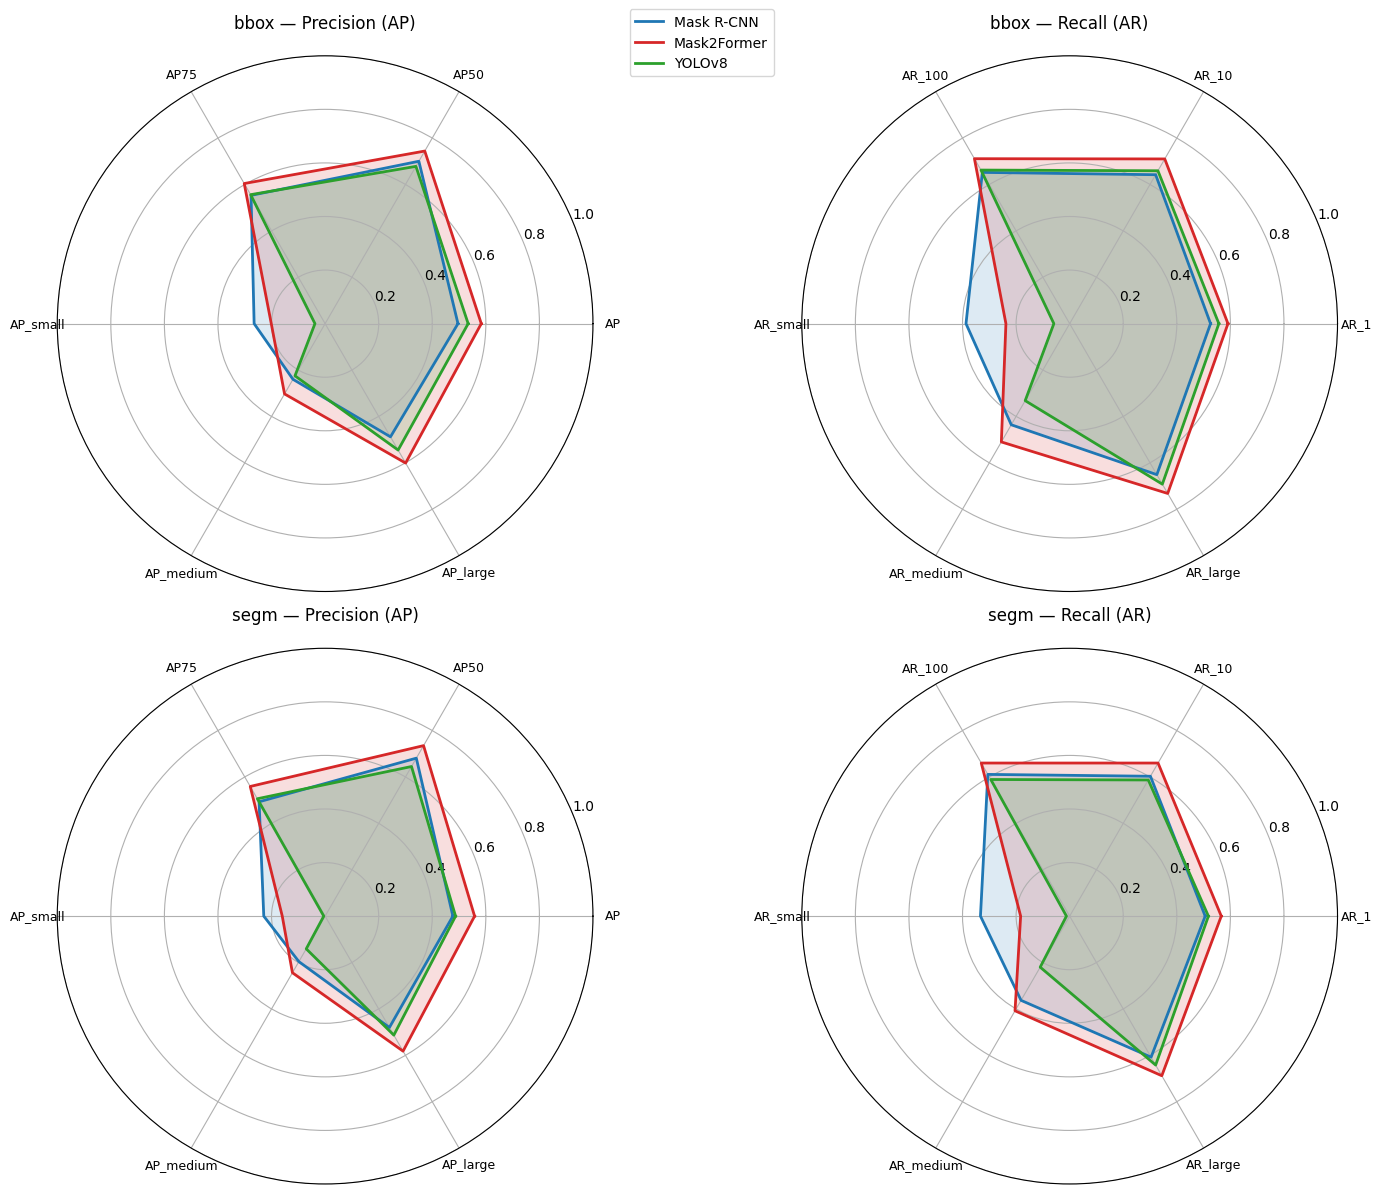

In [44]:
AP_AXES = ["AP", "AP50", "AP75", "AP_small", "AP_medium", "AP_large"]
AR_AXES = ["AR_1", "AR_10", "AR_100", "AR_small", "AR_medium", "AR_large"]
COLORS = {"Mask R-CNN": "tab:blue", "Mask2Former": "tab:red", "YOLOv8": "tab:green"}


def radar(ax, df, axes_names, title):
    angles = np.linspace(0, 2 * np.pi, len(axes_names), endpoint=False).tolist()
    angles += angles[:1]
    for name in df.columns:
        vals = df.loc[axes_names, name].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, color=COLORS[name], linewidth=2, label=name)
        ax.fill(angles, vals, color=COLORS[name], alpha=0.15)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(axes_names, fontsize=9)
    ax.set_ylim(0, 1); ax.set_title(title, pad=20)


fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw={"projection": "polar"})
radar(axes[0, 0], df_stats["bbox"], AP_AXES, "bbox — Precision (AP)")
radar(axes[0, 1], df_stats["bbox"], AR_AXES, "bbox — Recall (AR)")
radar(axes[1, 0], df_stats["segm"], AP_AXES, "segm — Precision (AP)")
radar(axes[1, 1], df_stats["segm"], AR_AXES, "segm — Recall (AR)")
axes[0, 0].legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout(); plt.show()

Видим, что площадь у `Mask2Former` **значительно** больше всех других моделей. То есть в большинстве метрик `Mask r-cnn` и `YOLOv8` проигрыва.т, **кроме работы с маленькими объектами**. На них особо явно просаживаются метрики у всех моделей, `Mask2Former` даже  уступает них `Mask r-cnn`. Особо это заметно на полноте (Recall).

## 4. Подсчёт по классам

В этом разделе предсказания фильтруются порогом **score ≥ 0.5** у обеих моделей.

Сравниваем для каждой тест-картинки — число объектов каждого класса и число предсказаний этого класса; правильность местоположения НЕ проверяется, только счёт.

Метрика `exact_%` — доля картинок с точным числом в рамках категории.

In [53]:
SCORE_THRESH_PROD = 0.5

filtered = {name: [r for r in res if r["score"] >= SCORE_THRESH_PROD]
            for name, res in results.items()}

from collections import defaultdict
preds_by_img = {name: defaultdict(list) for name in models}
for name in models:
    for r in filtered[name]:
        preds_by_img[name][r["image_id"]].append(r)

count_rows = []
for img_id in img_ids:
    gt_cnt = Counter(a["category_id"] - 1 for a in coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id)))
    for name in models:
        pred_cnt = Counter(r["category_id"] - 1 for r in preds_by_img[name][img_id])
        for c in range(NUM_CLASSES):
            count_rows.append({"model": name, "image_id": img_id, "class": CLASS_NAMES[c],
                               "gt": gt_cnt.get(c, 0), "pred": pred_cnt.get(c, 0)})

df_counts = pd.DataFrame(count_rows)
df_counts["err"] = df_counts["pred"] - df_counts["gt"]

summary = df_counts.groupby(["model", "class"]).apply(lambda g: pd.Series({
    "exact_%": 100 * (g["err"] == 0).mean()}), include_groups=False).round(3)
summary


exact_%
model       class                 
Mask R-CNN  crack           87.433
            dent            57.219
            glass_shatter   97.594
            lamp_broken     91.444
            scratch         58.289
            tire_flat       98.396
Mask2Former crack           88.770
            dent            64.706
            glass_shatter   97.861
            lamp_broken     90.107
            scratch         58.824
            tire_flat       97.326
YOLOv8      crack           88.503
            dent            75.668
            glass_shatter   97.861
            lamp_broken     91.979
            scratch         66.043
            tire_flat       97.326

Интрепретация метрик:
- видим, что самыми проблемными классами являются `scratch` и `dent`. Обе модели тяжело их распознают. Важно также и то, что эти классы самые объемные в выборке.
- число `dent` на картинке значительно лучше предсказывает `YOLOv8`. Поэтому средний процент точных попаданий в число предсказаний у него выше.

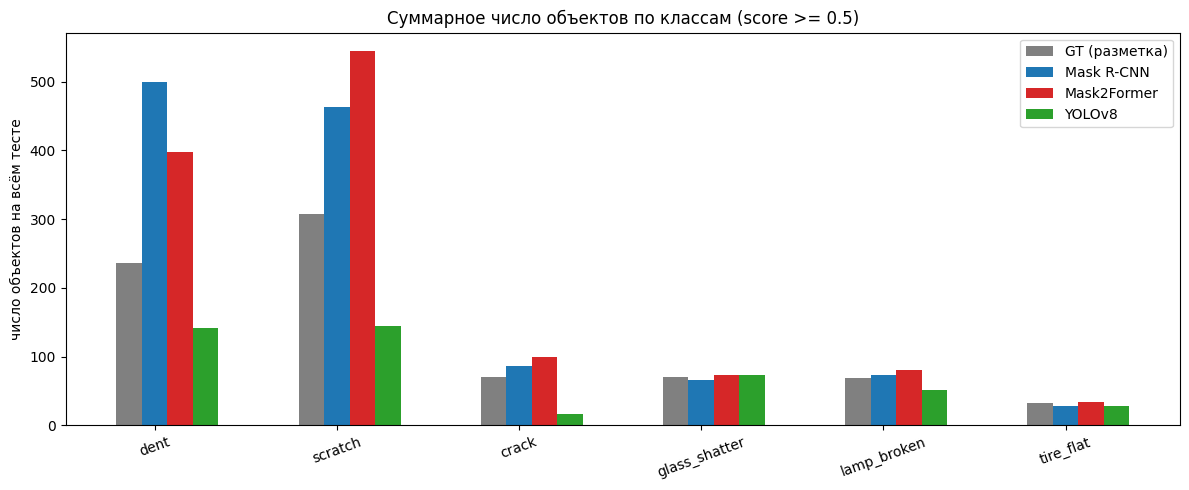

In [54]:
totals = df_counts.groupby(["model", "class"])[["gt", "pred"]].sum().reset_index()
x = np.arange(len(CLASS_NAMES)); w = 0.14

fig, ax = plt.subplots(figsize=(12, 5))
gt_vals = [totals[(totals["model"] == "Mask R-CNN") & (totals["class"] == c)]["gt"].iloc[0]
           for c in CLASS_NAMES]
ax.bar(x - w, gt_vals, w, label="GT (разметка)", color="gray")
for i, name in enumerate(models):
    vals = [totals[(totals["model"] == name) & (totals["class"] == c)]["pred"].iloc[0]
            for c in CLASS_NAMES]
    ax.bar(x + i * w, vals, w, label=name, color=COLORS[name])
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=20)
ax.set_ylabel("число объектов на всём тесте"); ax.legend()
ax.set_title(f"Суммарное число объектов по классам (score >= {SCORE_THRESH_PROD})")
plt.tight_layout(); plt.show()

График подствердил наблюдения на метркиах. Он показал как самые проблемыне классы, так и те, с которыми модели справляются лучше.


## 5. Бизнес выводы и заключение

В итоге нам нужно выбрать финальную модель, которую будем использовать для автоматизации процессов.

Сначала сравним `Mask R-CNN` и `Mask2Foemer`. Видиим, что они довольно похожи по метрикам и результатам, но `Mask2Foemer` стабильно outperform'ит на всех метрках, кроме нахождения маленьких объектов. Однако тк обе модли довольно тяжеловесные, выбрать нужно одну. И это `Mask2Foemer` как модель с более быстрым инференсом и overall лучшими метриками.

Потом сравним `YOLOv8` и `Mask2Foemer`. Оснвная разница между ними - объем модели. Несмотря на то, что в некоторых метриках `YOLOv8` почти не уступает, просадка модели на маленьких объектах вплоть до нуля делает невозможным ее применение в проду. Также интересное качество `YOLOv8` - занижать число предсказаний по классу на картинке. Нам же важно ошибаться в другую сторону и быть уверенными, что у нас полнота при работе над страховым случаем.

**Итоговая модель для нашей задачи -** `Mask2Foemer`


*бизнес-инсайды из данных*:  
- самые проблемные для обнаружения классы: `dent`, `scratch`. Это происхожит потому,что тяжело определить границы для, например, вмятины. Где кк начало, где конец а где неровность самой машины.
- обязательно требовать фотографии крупным планом! Качество критически мадает на маленьких предсказаниях.
- алгоритму нельзя делегировать подсчет цены на тех картиках, где есть `dent`, `scratch`. Однако если алгоритм не нашел этих классов, мы можем быть уверенны, что модель нашла правильное их количесво на фотографии.